<a href="https://colab.research.google.com/github/Khushibung05/NLP/blob/main/PE_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using Colab cache for faster access to the 'resume-dataset' dataset.
Dataset Path: /kaggle/input/resume-dataset

Files inside dataset:

/kaggle/input/resume-dataset/Resume/Resume.csv
/kaggle/input/resume-dataset/data/data/DESIGNER/22506245.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/13998435.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/67582956.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/34349255.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/26790545.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/12674307.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/11807040.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/44145704.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/27497542.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/11155153.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/17555081.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/41506705.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/54201930.pdf
/kaggle/input/resume-dat

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR



Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

Resume Text Column: Resume_str
Category Column: Category

BASIC DATASET INFORMATION
Number of resumes: 2484

Number of categories:
24

Categories:
['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' 'CHEF' 'FINANCE' 'APPAREL'
 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS' 'BANKING'
 'ARTS' 'AVIATION']

Average Resume Length:
811.33

Maximum Resume Length:
5190

Minimum Resume Length:
0


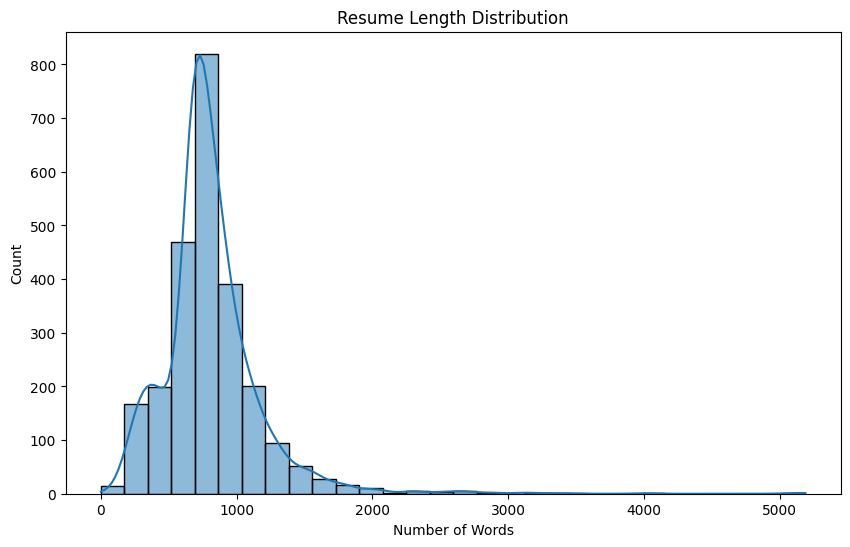

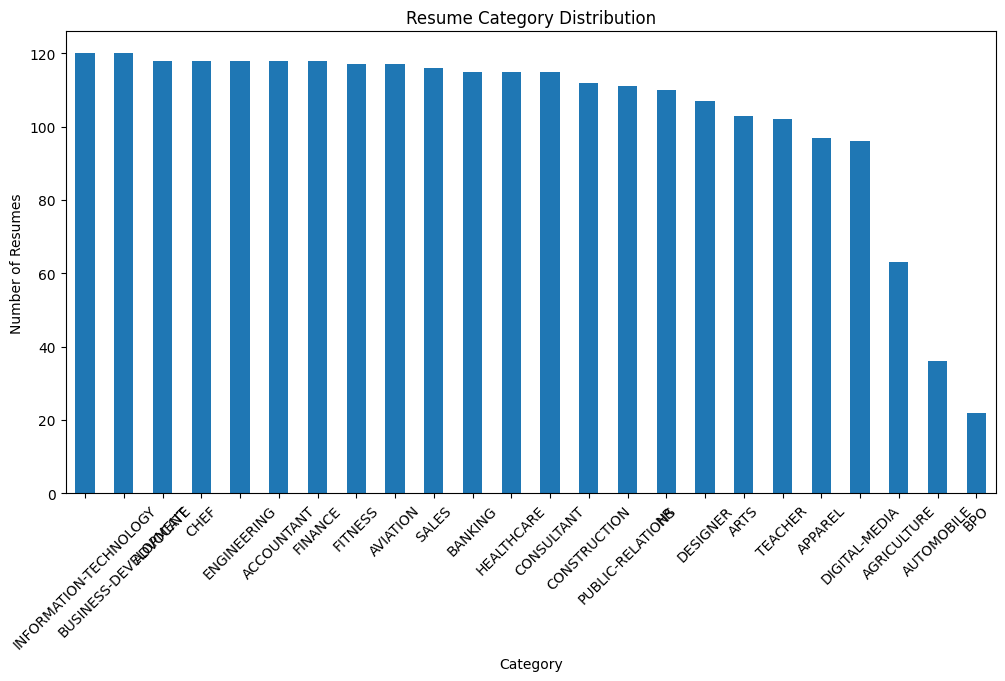


Top Skills:


,Skill,Frequency
3,c,568362
22,excel,3833
29,git,988
4,sql,828
25,aws,518
7,html,323
1,java,323
30,linux,233
8,css,168
2,c++,156


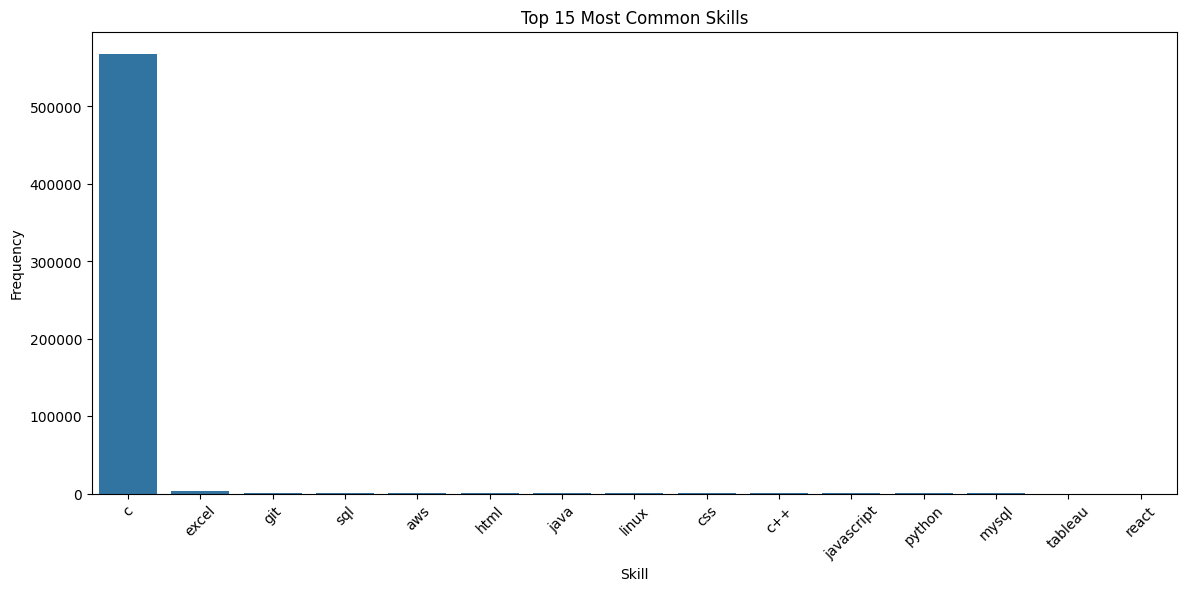

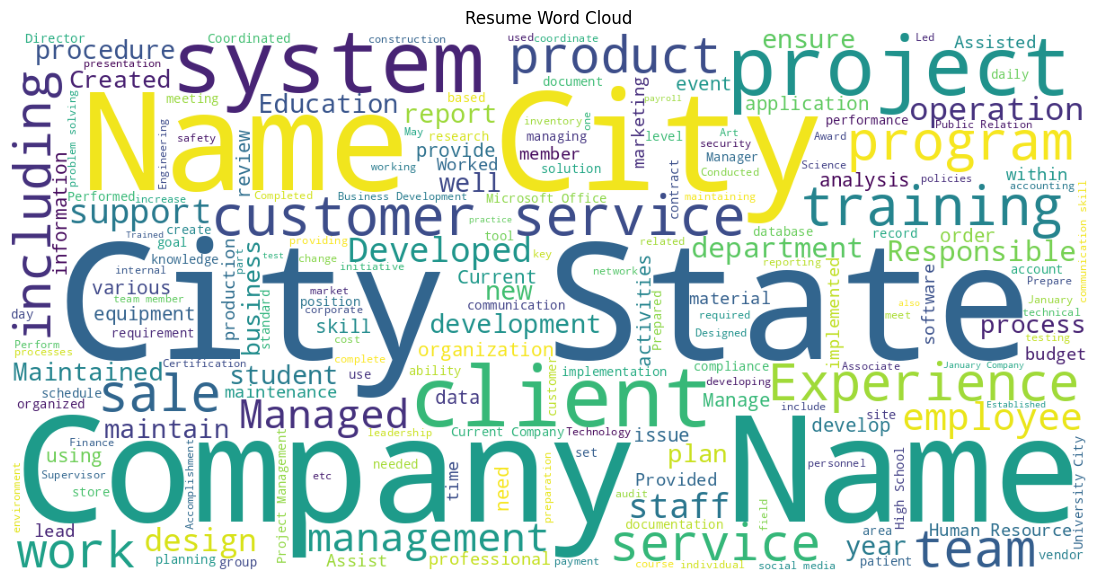


EDA SUMMARY
Total Resumes: 2484
Total Categories: 24
Average Resume Length: 811.33

Top 10 Skills:
    Skill  Frequency
3       c     568362
22  excel       3833
29    git        988
4     sql        828
25    aws        518
7    html        323
1    java        323
30  linux        233
8     css        168
2     c++        156


In [ ]:
# ============================================================
# TASK 1 - DATASET ANALYSIS (EDA)
# Resume Dataset
# ============================================================

# Install required libraries

# ============================================================
# IMPORTS
# ============================================================

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# ============================================================
# DOWNLOAD DATASET
# ============================================================

import kagglehub

path = kagglehub.dataset_download(
    "snehaanbhawal/resume-dataset"
)

print("Dataset Path:", path)

# ============================================================
# CHECK FILES
# ============================================================

print("\nFiles inside dataset:\n")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

# ============================================================
# LOAD DATASET
# ============================================================

csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("\nCSV Files Found:")
print(csv_files)

# Load first csv
df = pd.read_csv(csv_files[0])

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

# ============================================================
# COLUMN ANALYSIS
# ============================================================

print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# IDENTIFY RESUME COLUMN
# ============================================================

text_col = None

possible_text_cols = [
    "Resume",
    "resume",
    "Resume_str",
    "resume_text",
    "text"
]

for col in df.columns:
    if col in possible_text_cols:
        text_col = col
        break

if text_col is None:
    text_col = df.columns[0]

print("\nResume Text Column:", text_col)

# ============================================================
# IDENTIFY CATEGORY COLUMN
# ============================================================

category_col = None

possible_category_cols = [
    "Category",
    "category",
    "Resume_Category",
    "label"
]

for col in df.columns:
    if col in possible_category_cols:
        category_col = col
        break

print("Category Column:", category_col)

# ============================================================
# BASIC EDA
# ============================================================

print("\n============================")
print("BASIC DATASET INFORMATION")
print("============================")

print("Number of resumes:", len(df))

if category_col:
    print("\nNumber of categories:")
    print(df[category_col].nunique())

    print("\nCategories:")
    print(df[category_col].unique())

# ============================================================
# RESUME LENGTH ANALYSIS
# ============================================================

df["resume_length"] = (
    df[text_col]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("\nAverage Resume Length:")
print(round(df["resume_length"].mean(), 2))

print("\nMaximum Resume Length:")
print(df["resume_length"].max())

print("\nMinimum Resume Length:")
print(df["resume_length"].min())

# ============================================================
# VISUALIZATION 1
# RESUME LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["resume_length"],
    bins=30,
    kde=True
)

plt.title("Resume Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")

plt.show()

# ============================================================
# CATEGORY DISTRIBUTION
# ============================================================

if category_col:

    plt.figure(figsize=(12,6))

    df[category_col].value_counts().plot(
        kind="bar"
    )

    plt.title("Resume Category Distribution")
    plt.xlabel("Category")
    plt.ylabel("Number of Resumes")

    plt.xticks(rotation=45)

    plt.show()

# ============================================================
# SKILL EXTRACTION
# ============================================================

skill_list = [

    "python",
    "java",
    "c++",
    "c",
    "sql",
    "mysql",
    "mongodb",
    "html",
    "css",
    "javascript",
    "react",
    "angular",
    "nodejs",
    "django",
    "flask",
    "tensorflow",
    "keras",
    "pytorch",
    "machine learning",
    "deep learning",
    "nlp",
    "data science",
    "excel",
    "power bi",
    "tableau",
    "aws",
    "azure",
    "docker",
    "kubernetes",
    "git",
    "linux"
]

# ============================================================
# COUNT SKILLS
# ============================================================

all_text = " ".join(
    df[text_col]
    .astype(str)
    .str.lower()
)

skill_counter = {}

for skill in skill_list:

    count = len(
        re.findall(
            re.escape(skill),
            all_text
        )
    )

    skill_counter[skill] = count

skill_df = pd.DataFrame(
    skill_counter.items(),
    columns=["Skill", "Frequency"]
)

skill_df = skill_df.sort_values(
    by="Frequency",
    ascending=False
)

print("\nTop Skills:")
display(skill_df.head(20))

# ============================================================
# VISUALIZATION 2
# SKILL FREQUENCY CHART
# ============================================================

plt.figure(figsize=(14,6))

sns.barplot(
    data=skill_df.head(15),
    x="Skill",
    y="Frequency"
)

plt.title("Top 15 Most Common Skills")
plt.xticks(rotation=45)

plt.show()

# ============================================================
# WORD CLOUD
# ============================================================

stop_words = set(stopwords.words('english'))

text = " ".join(
    df[text_col]
    .astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stop_words
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume Word Cloud")

plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n============================")
print("EDA SUMMARY")
print("============================")

print("Total Resumes:", len(df))

if category_col:
    print("Total Categories:", df[category_col].nunique())

print(
    "Average Resume Length:",
    round(df["resume_length"].mean(),2)
)

print("\nTop 10 Skills:")

print(
    skill_df.head(10)
)

In [ ]:
# ============================================================
# TASK 2 - TEXT PREPROCESSING
# ============================================================

import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# CLEANING FUNCTION
# ============================================================

def preprocess_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', ' ', text)

    # Remove Emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove Numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove Special Characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove Extra Spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ============================================================
# APPLY PREPROCESSING
# ============================================================

df["clean_resume"] = df[text_col].apply(preprocess_text)

print("Original Resume:\n")
print(df[text_col].iloc[0][:500])

print("\n\nCleaned Resume:\n")
print(df["clean_resume"].iloc[0][:500])

# ============================================================
# TOKENIZATION
# ============================================================

MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_resume"])

# Convert text to integer sequences
sequences = tokenizer.texts_to_sequences(
    df["clean_resume"]
)

print("\nSample Tokenized Resume:\n")
print(sequences[0][:50])

# ============================================================
# VOCABULARY CREATION
# ============================================================

word_index = tokenizer.word_index

vocab_size = len(word_index) + 1

print("\nVocabulary Size:")
print(vocab_size)

print("\nFirst 20 Vocabulary Words:")

for i, (word, idx) in enumerate(word_index.items()):
    print(word, "->", idx)

    if i == 19:
        break

# ============================================================
# RESUME LENGTH ANALYSIS
# ============================================================

sequence_lengths = [
    len(seq)
    for seq in sequences
]

print("\nAverage Token Length:")
print(np.mean(sequence_lengths))

print("\nMaximum Token Length:")
print(np.max(sequence_lengths))

print("\nMinimum Token Length:")
print(np.min(sequence_lengths))

# ============================================================
# CHOOSE MAX LENGTH
# ============================================================

MAX_LEN = 300

# You can also use:
# MAX_LEN = int(np.percentile(sequence_lengths,95))

print("\nSelected MAX_LEN =", MAX_LEN)

# ============================================================
# PADDING
# ============================================================

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("\nPadded Shape:")
print(padded_sequences.shape)

# ============================================================
# SAMPLE OUTPUT
# ============================================================

print("\nFirst Resume After Padding:\n")

print(
    padded_sequences[0][:100]
)

# ============================================================
# SAVE PREPROCESSED DATA
# ============================================================

np.save(
    "resume_sequences.npy",
    padded_sequences
)

print("\nPreprocessed sequences saved.")

# ============================================================
# SUMMARY
# ============================================================

print("\n==========================")
print("TASK 2 COMPLETED")
print("==========================")

print("Total Resumes :", len(df))
print("Vocabulary Size :", vocab_size)
print("Sequence Shape :", padded_sequences.shape)
print("Max Length :", MAX_LEN)

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


Cleaned Resume:

hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relati

Task 3: Build Baseline Model (Without Positional Encoding)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Category column from Task 1
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df[category_col])

num_classes = len(np.unique(y))

y = to_categorical(y)

print("Number of Classes:", num_classes)
print("Label Shape:", y.shape)

Number of Classes: 24
Label Shape: (2484, 24)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1987, 300)
(497, 300)


In [ ]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    Dense,
    GlobalAveragePooling1D,
    LayerNormalization,
    Dropout
)

from tensorflow.keras.models import Model

In [ ]:
MAX_LEN = padded_sequences.shape[1]

EMBED_DIM = 128
NUM_HEADS = 4

inputs = Input(shape=(MAX_LEN,))

# Embedding Layer
x = Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM
)(inputs)

# Self Attention
attention_output = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM
)(
    x,
    x
)

# Residual Connection
x = attention_output + x

# Normalization
x = LayerNormalization()(x)

# Pooling
x = GlobalAveragePooling1D()(x)

# Dense Layer
x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    num_classes,
    activation='softmax'
)(x)

baseline_model = Model(
    inputs,
    outputs
)

baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  4,816,640 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │    263,808 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 300, 128)  │          0 │ multi_head_atten… │
│                     │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 300, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24)        │      3,096 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,100,312 (19.46 MB)

 Trainable params: 5,100,312 (19.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import time

start_time = time.time()

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Time:")
print(round(training_time,2), "seconds")

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.1717 - loss: 2.9157 - val_accuracy: 0.4221 - val_loss: 2.2965
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.4894 - loss: 1.8116 - val_accuracy: 0.5327 - val_loss: 1.7745
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7383 - loss: 0.9375 - val_accuracy: 0.6432 - val_loss: 1.3207
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9038 - loss: 0.3696 - val_accuracy: 0.6432 - val_loss: 1.4303
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9720 - loss: 0.1391 - val_accuracy: 0.6382 - val_loss: 1.5631
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9911 - loss: 0.0525 - val_accuracy: 0.6633 - val_loss: 1.5858
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9978 - loss: 0.0277 - val_accuracy: 0.6482 - val_loss: 1.7279
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9989 - loss: 0.0157 - val_accuracy: 0.6633 -

In [ ]:
loss, accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n======================")
print("BASELINE RESULTS")
print("======================")

print("Test Accuracy :", round(accuracy*100,2), "%")
print("Test Loss     :", round(loss,4))
print("Training Time :", round(training_time,2), "sec")


BASELINE RESULTS
Test Accuracy : 66.4 %
Test Loss     : 1.8317
Training Time : 35.92 sec


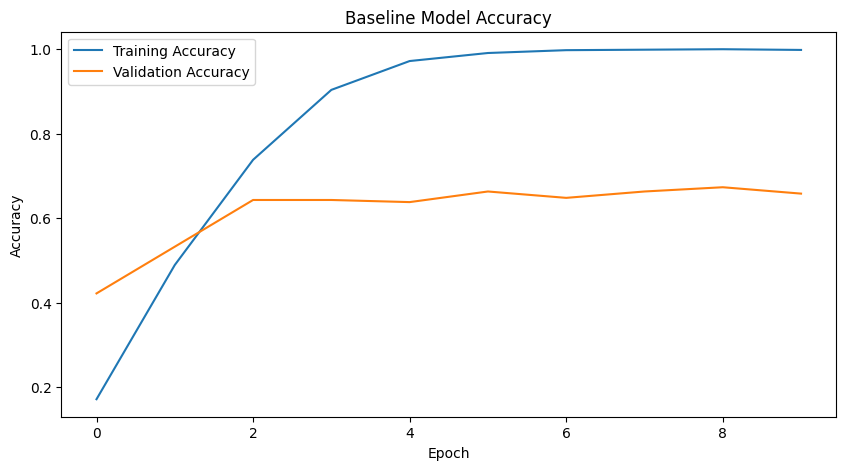

In [ ]:
#ACCURACY PLOT
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

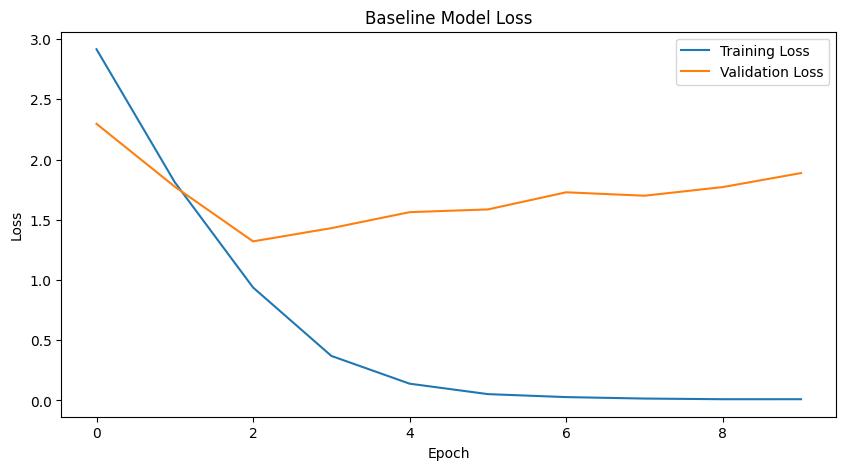

In [ ]:
#LOSS PLOT
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

##### TASK 4
##### TRANSFORMER WITH POSITIONAL ENCODING

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 128)  │  4,816,640 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 300, 128)  │          0 │ embedding_1[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │    263,808 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 300, 128)  │          0 │ multi_head_atten… │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 300, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24)        │      3,096 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,100,312 (19.46 MB)

 Trainable params: 5,100,312 (19.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.0425 - loss: 3.2230 - val_accuracy: 0.0653 - val_loss: 3.1568
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0403 - loss: 3.1783 - val_accuracy: 0.0653 - val_loss: 3.1711
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0526 - loss: 3.1683 - val_accuracy: 0.0503 - val_loss: 3.1506
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0565 - loss: 3.1488 - val_accuracy: 0.0704 - val_loss: 3.1692
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1376 - loss: 2.8392 - val_accuracy: 0.2613 - val_loss: 2.3923
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4251 - loss: 1.9450 - val_accuracy: 0.5578 - val_loss: 1.5505
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6348 - loss: 1.3067 - val_accuracy: 0.6734 - val_loss: 1.3896
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6980 - loss: 1.0410 - val_accuracy: 0.6734 -

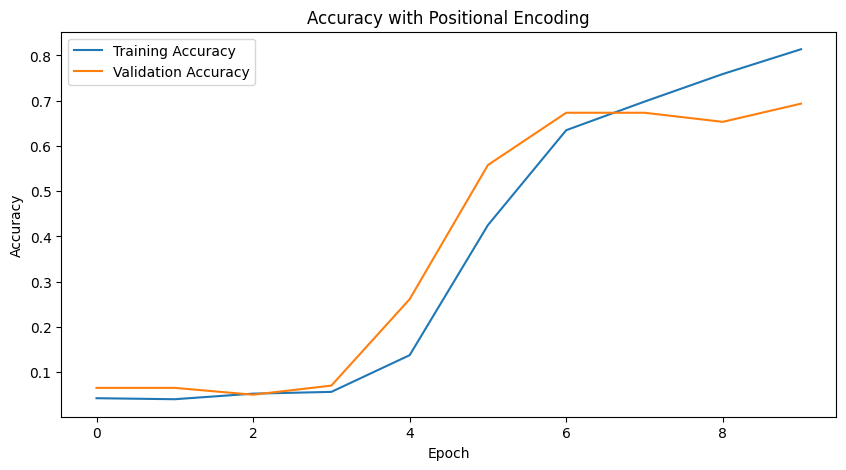

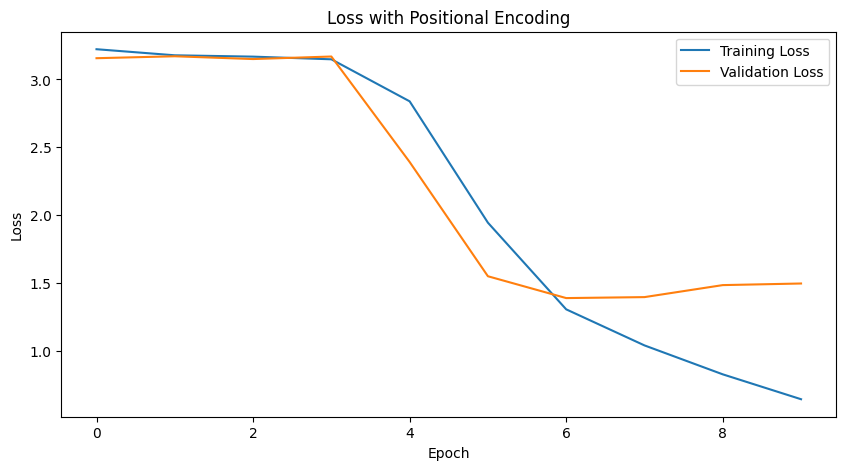


Sample Positional Encoding Matrix:
[[ 0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00
   0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00
   0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00
   0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00]
 [ 8.4147096e-01  5.4030228e-01  3.1098360e-01  9.5041525e-01
   9.9833414e-02  9.9500418e-01  3.1617507e-02  9.9950004e-01
   9.9998331e-03  9.9994999e-01  3.1622723e-03  9.9999499e-01
   9.9999981e-04  9.9999952e-01  3.1622776e-04  9.9999994e-01]
 [ 9.0929741e-01 -4.1614684e-01  5.9112710e-01  8.0657840e-01
   1.9866933e-01  9.8006660e-01  6.3203394e-02  9.9800068e-01
   1.9998666e-02  9.9980003e-01  6.3245133e-03  9.9997997e-01
   1.9999987e-03  9.9999797e-01  6.3245551e-04  9.9999982e-01]
 [ 1.4112000e-01 -9.8999250e-01  8.1264889e-01  5.8275360e-01
   2.9552022e-01  9.5533651e-01  9.4726093e-02  9.9550337e-01
   2.9995501e-02  9.9955004e-01  9.4866911e-03  9.9995500e-01
   2.9999956e-03  9.9999553e-01

In [ ]:
# ============================================================
# TASK 4
# TRANSFORMER WITH POSITIONAL ENCODING
# ============================================================

import numpy as np
import tensorflow as tf
import time

from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    Dense,
    LayerNormalization,
    GlobalAveragePooling1D,
    Dropout
)

from tensorflow.keras.models import Model

# ============================================================
# POSITIONAL ENCODING FUNCTION
# ============================================================

def position_encoding(position, d_model):

    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2))
        / np.float32(d_model)
    )

    pos_encoding = np.zeros((position, d_model))

    # Even dimensions -> sin
    pos_encoding[:, 0::2] = np.sin(
        angle_rads[:, 0::2]
    )

    # Odd dimensions -> cos
    pos_encoding[:, 1::2] = np.cos(
        angle_rads[:, 1::2]
    )

    pos_encoding = pos_encoding[np.newaxis, ...]

    return tf.cast(pos_encoding, dtype=tf.float32)

# ============================================================
# CUSTOM POSITIONAL ENCODING LAYER
# ============================================================

class PositionalEncoding(tf.keras.layers.Layer):

    def __init__(self, max_len, d_model):
        super().__init__()

        self.pos_encoding = position_encoding(
            max_len,
            d_model
        )

    def call(self, x):

        seq_len = tf.shape(x)[1]

        return x + self.pos_encoding[:, :seq_len, :]

# ============================================================
# PARAMETERS
# ============================================================

MAX_LEN = padded_sequences.shape[1]

EMBED_DIM = 128

NUM_HEADS = 4

# ============================================================
# BUILD MODEL
# ============================================================

inputs = Input(shape=(MAX_LEN,))

# ------------------------------------------------
# WORD EMBEDDINGS
# ------------------------------------------------

x = Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM
)(inputs)

# ------------------------------------------------
# ADD POSITION INFORMATION
# ------------------------------------------------

x = PositionalEncoding(
    MAX_LEN,
    EMBED_DIM
)(x)

# ------------------------------------------------
# MULTI HEAD SELF ATTENTION
# ------------------------------------------------

attention_output = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM
)(
    x,
    x
)

# Residual Connection
x = attention_output + x

# Layer Normalization
x = LayerNormalization()(x)

# ------------------------------------------------
# CLASSIFICATION HEAD
# ------------------------------------------------

x = GlobalAveragePooling1D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    num_classes,
    activation='softmax'
)(x)

# ============================================================
# MODEL
# ============================================================

pe_model = Model(
    inputs,
    outputs
)

pe_model.summary()

# ============================================================
# COMPILE
# ============================================================

pe_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# TRAINING
# ============================================================

start_time = time.time()

history_pe = pe_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

end_time = time.time()

training_time_pe = end_time - start_time

# ============================================================
# EVALUATION
# ============================================================

loss_pe, accuracy_pe = pe_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("POSITIONAL ENCODING RESULTS")
print("==============================")

print(
    "Accuracy :",
    round(accuracy_pe * 100, 2),
    "%"
)

print(
    "Loss :",
    round(loss_pe, 4)
)

print(
    "Training Time :",
    round(training_time_pe, 2),
    "seconds"
)

# ============================================================
# ACCURACY GRAPH
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_pe.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_pe.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Accuracy with Positional Encoding'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

# ============================================================
# LOSS GRAPH
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    history_pe.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_pe.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Loss with Positional Encoding'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

# ============================================================
# DISPLAY SAMPLE POSITIONAL ENCODING
# ============================================================

sample_pe = position_encoding(
    10,
    16
)

print("\nSample Positional Encoding Matrix:")
print(sample_pe.numpy()[0])

##### TASK 5 : IMPROVED MODEL WITH POSITIONAL ENCODING

In [ ]:
# ============================================================
# TASK 5 : IMPROVED MODEL WITH POSITIONAL ENCODING
# ============================================================

import tensorflow as tf
import numpy as np
import time

from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    Dense,
    GlobalAveragePooling1D,
    LayerNormalization,
    Dropout
)

from tensorflow.keras.models import Model

# ============================================================
# POSITIONAL ENCODING
# ============================================================

def position_encoding(position, d_model):

    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2))
        / np.float32(d_model)
    )

    pos_encoding = np.zeros((position, d_model))

    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])

    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(
        pos_encoding[np.newaxis, ...],
        dtype=tf.float32
    )

# ============================================================
# CUSTOM POSITIONAL ENCODING LAYER
# ============================================================

class PositionalEncoding(tf.keras.layers.Layer):

    def __init__(self, max_len, d_model):
        super().__init__()

        self.pos_encoding = position_encoding(
            max_len,
            d_model
        )

    def call(self, x):

        seq_len = tf.shape(x)[1]

        return x + self.pos_encoding[:, :seq_len, :]

# ============================================================
# MODEL PARAMETERS
# ============================================================

EMBED_DIM = 128
NUM_HEADS = 4
MAX_LEN = padded_sequences.shape[1]

# ============================================================
# MODEL
# ============================================================

inputs = Input(shape=(MAX_LEN,))

x = Embedding(
    vocab_size,
    EMBED_DIM
)(inputs)

x = PositionalEncoding(
    MAX_LEN,
    EMBED_DIM
)(x)

attention = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM
)(x, x)

x = attention + x

x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    num_classes,
    activation='softmax'
)(x)

improved_model = Model(
    inputs,
    outputs
)

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

# ============================================================
# TRAIN
# ============================================================

start_time = time.time()

history_improved = improved_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

training_time_improved = time.time() - start_time

# ============================================================
# EVALUATE
# ============================================================

loss_improved, accuracy_improved = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nAccuracy :", accuracy_improved)
print("Loss :", loss_improved)
print("Training Time :", training_time_improved)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 300, 128)  │  4,816,640 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 300, 128)  │          0 │ embedding_2[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │    263,808 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 300, 128)  │          0 │ multi_head_atten… │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 300, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 24)        │      3,096 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,100,312 (19.46 MB)

 Trainable params: 5,100,312 (19.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.0375 - loss: 3.2148 - val_accuracy: 0.0653 - val_loss: 3.1552
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0515 - loss: 3.1656 - val_accuracy: 0.0201 - val_loss: 3.1632
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0487 - loss: 3.1557 - val_accuracy: 0.0251 - val_loss: 3.1645
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0917 - loss: 3.0081 - val_accuracy: 0.2663 - val_loss: 2.5704
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3227 - loss: 2.2714 - val_accuracy: 0.5678 - val_loss: 1.7577
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5503 - loss: 1.5804 - val_accuracy: 0.6683 - val_loss: 1.3346
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6516 - loss: 1.2589 - val_accuracy: 0.6834 - val_loss: 1.2660
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7232 - loss: 1.0236 - val_accuracy: 0.6482 - 

####Compare Results

In [ ]:
# ============================================================
# TASK 6 : COMPARISON
# ============================================================

print("\n")
print("="*60)
print("COMPARISON OF MODELS")
print("="*60)

print(f"{'Metric':<20}{'Without PE':<20}{'With PE':<20}")

print("-"*60)

print(
    f"{'Accuracy':<20}"
    f"{accuracy*100:.2f}%{'':<10}"
    f"{accuracy_improved*100:.2f}%"
)

print(
    f"{'Loss':<20}"
    f"{loss:.4f}{'':<12}"
    f"{loss_improved:.4f}"
)

print(
    f"{'Training Time':<20}"
    f"{training_time:.2f}s{'':<10}"
    f"{training_time_improved:.2f}s"
)



COMPARISON OF MODELS
Metric              Without PE          With PE             
------------------------------------------------------------
Accuracy            66.40%          68.81%
Loss                1.8317            1.5449
Training Time       35.92s          21.67s


###Demonstrating Word importance

Sentence 1 Tokens
[2533, 1509, 8, 1, 106, 29, 6, 6940]

Sentence 2 Tokens
[6940, 29, 8, 2533, 1509, 1, 106]

Sentence 1
Python developer with 5 years experience in AI

Sentence 2
AI experience with Python developer 5 years

Same Words?
False

First 3 Position Encodings

Position 0
[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]

Position 1
[8.4147096e-01 5.4030228e-01 3.1098360e-01 9.5041525e-01 9.9833414e-02
 9.9500418e-01 3.1617507e-02 9.9950004e-01 9.9998331e-03 9.9994999e-01
 3.1622723e-03 9.9999499e-01 9.9999981e-04 9.9999952e-01 3.1622776e-04
 9.9999994e-01]

Position 2
[ 9.0929741e-01 -4.1614684e-01  5.9112710e-01  8.0657840e-01
  1.9866933e-01  9.8006660e-01  6.3203394e-02  9.9800068e-01
  1.9998666e-02  9.9980003e-01  6.3245133e-03  9.9997997e-01
  1.9999987e-03  9.9999797e-01  6.3245551e-04  9.9999982e-01]


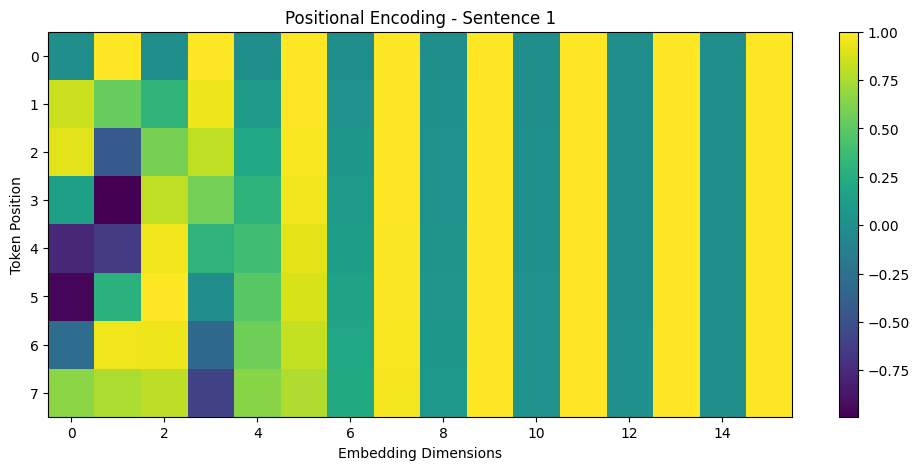

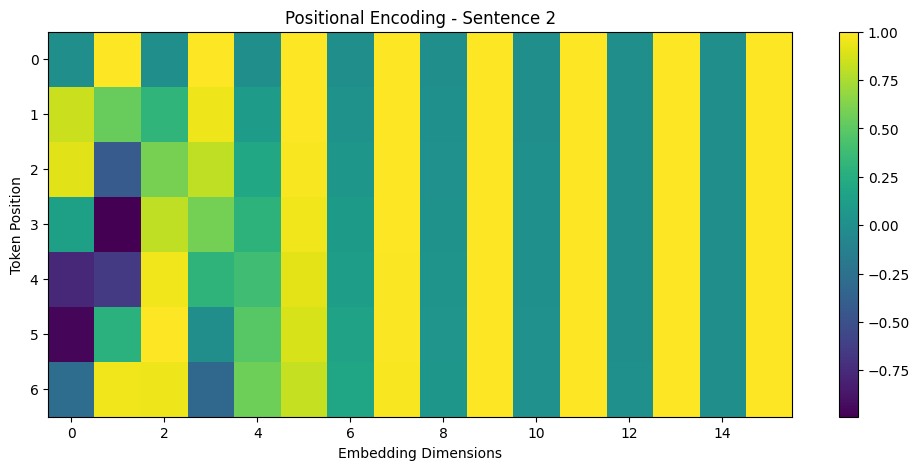

In [ ]:
# ============================================================
# TASK 7 : WORD ORDER DEMONSTRATION
# ============================================================

sentence1 = "Python developer with 5 years experience in AI"

sentence2 = "AI experience with Python developer 5 years"

# ============================================================
# TOKENIZE
# ============================================================

seq1 = tokenizer.texts_to_sequences([sentence1])[0]
seq2 = tokenizer.texts_to_sequences([sentence2])[0]

print("Sentence 1 Tokens")
print(seq1)

print("\nSentence 2 Tokens")
print(seq2)

# ============================================================
# POSITIONAL ENCODING
# ============================================================

d_model = 16

pe1 = position_encoding(
    len(seq1),
    d_model
).numpy()[0]

pe2 = position_encoding(
    len(seq2),
    d_model
).numpy()[0]

print("\nSentence 1")
print(sentence1)

print("\nSentence 2")
print(sentence2)

print("\nSame Words?")
print(
    set(sentence1.lower().split()) ==
    set(sentence2.lower().split())
)

print("\nFirst 3 Position Encodings")

print("\nPosition 0")
print(pe1[0])

print("\nPosition 1")
print(pe1[1])

print("\nPosition 2")
print(pe1[2])

# ============================================================
# VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.imshow(
    pe1,
    aspect='auto'
)

plt.colorbar()

plt.title(
    "Positional Encoding - Sentence 1"
)

plt.xlabel("Embedding Dimensions")

plt.ylabel("Token Position")

plt.show()

plt.figure(figsize=(12,5))

plt.imshow(
    pe2,
    aspect='auto'
)

plt.colorbar()

plt.title(
    "Positional Encoding - Sentence 2"
)

plt.xlabel("Embedding Dimensions")

plt.ylabel("Token Position")

plt.show()

Sentence 1:
Python developer with 5 years experience in AI

Sentence 2:
AI experience with Python developer 5 years

Same Words: True

Same Order: False

Different Positional Encodings: True

Embedding captures WHAT the words mean.

Positional Encoding captures WHERE the words occur.

Embedding + Positional Encoding allows
Multi-Head Attention to understand both
meaning and order.

Shape:
(100, 128)


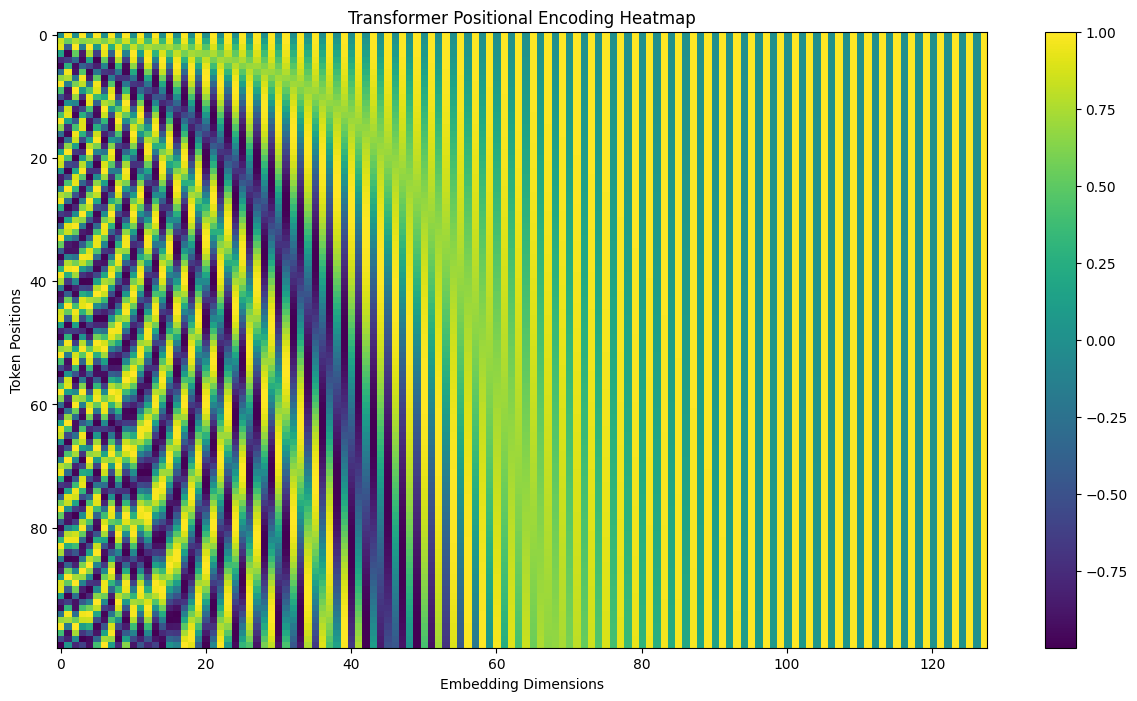

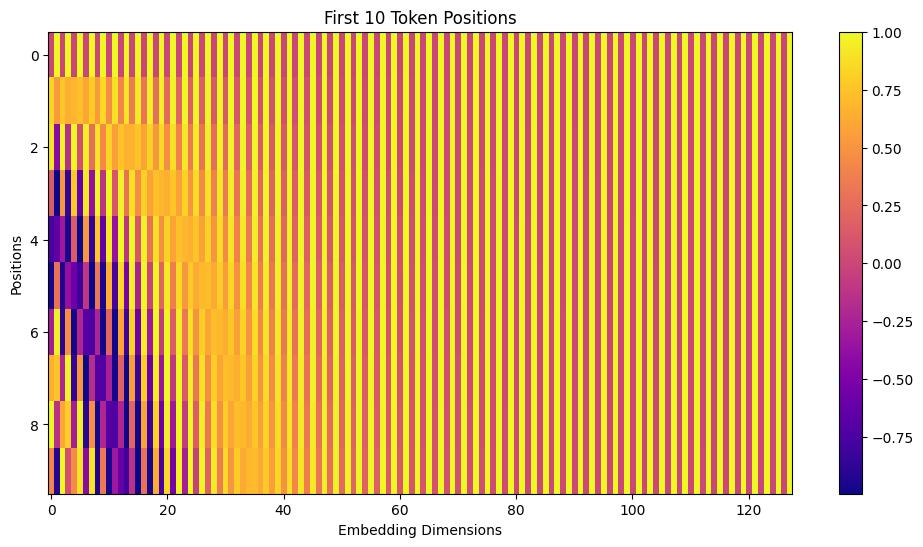


Position 1 Encoding:
[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]

Position 2 Encoding:
[0.84147098 0.54030231 0.76172041 0.64790587 0.68156135 0.73176098
 0.60469402 0.79645787 0.53316844 0.84600911 0.46794808 0.88375596
 0.40930892 0.91239586 0.35711195 0.93406159 0.31098359 0.95041528
 0.27043223 0.96273901]

Position 3 Encoding:
[ 0.90929743 -0.41614684  0.98704625 -0.16043596  0.99748     0.07094825
  0.96322662  0.26869029  0.90213071  0.43146283  0.8271038   0.5620492
  0.74690354  0.66493241  0.6671291   0.74494212  0.59112712  0.80657841
  0.52071132  0.85373282]


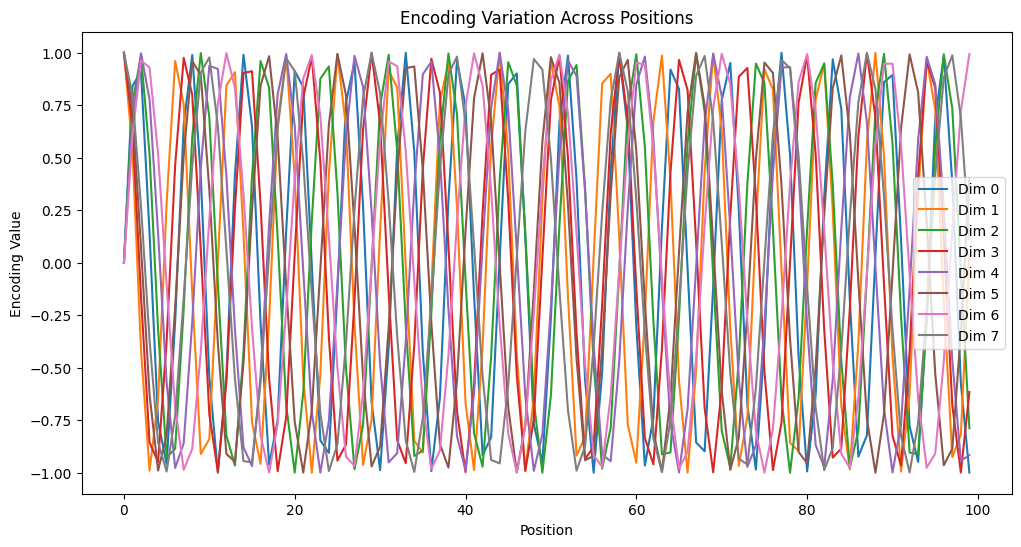

In [ ]:
# ============================================================
# TASK 8 : POSITIONAL ENCODING VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# POSITIONAL ENCODING FUNCTION
# ============================================================

def position_encoding(position, d_model):

    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2))
        / np.float32(d_model)
    )

    pos_encoding = np.zeros((position, d_model))

    pos_encoding[:, 0::2] = np.sin(
        angle_rads[:, 0::2]
    )

    pos_encoding[:, 1::2] = np.cos(
        angle_rads[:, 1::2]
    )

    return pos_encoding

# ============================================================
# CREATE POSITIONAL ENCODING MATRIX
# ============================================================

MAX_POSITION = 100

D_MODEL = 128

positional_encoding_matrix = position_encoding(
    MAX_POSITION,
    D_MODEL
)

print("Shape:")
print(positional_encoding_matrix.shape)

# ============================================================
# HEATMAP
# ============================================================

plt.figure(figsize=(15,8))

plt.imshow(
    positional_encoding_matrix,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()

plt.xlabel("Embedding Dimensions")

plt.ylabel("Token Positions")

plt.title(
    "Transformer Positional Encoding Heatmap"
)

plt.show()

# ============================================================
# VISUALIZE FIRST 10 POSITIONS
# ============================================================

plt.figure(figsize=(12,6))

plt.imshow(
    positional_encoding_matrix[:10],
    aspect='auto',
    cmap='plasma'
)

plt.colorbar()

plt.xlabel("Embedding Dimensions")

plt.ylabel("Positions")

plt.title(
    "First 10 Token Positions"
)

plt.show()

# ============================================================
# POSITION COMPARISON
# ============================================================

print("\nPosition 1 Encoding:")
print(positional_encoding_matrix[0][:20])

print("\nPosition 2 Encoding:")
print(positional_encoding_matrix[1][:20])

print("\nPosition 3 Encoding:")
print(positional_encoding_matrix[2][:20])

# ============================================================
# PLOT FEW DIMENSIONS ACROSS POSITIONS
# ============================================================

plt.figure(figsize=(12,6))

for i in range(8):
    plt.plot(
        positional_encoding_matrix[:, i],
        label=f'Dim {i}'
    )

plt.title(
    "Encoding Variation Across Positions"
)

plt.xlabel("Position")

plt.ylabel("Encoding Value")

plt.legend()

plt.show()

In [ ]:
# ============================================================
# TASK 9 : SAVE MODEL AND OBJECTS
# ============================================================

import pickle

# ============================================================
# SAVE MODEL
# ============================================================

improved_model.save(
    "model.keras"
)

print("Model Saved")

# ============================================================
# SAVE TOKENIZER
# ============================================================

with open(
    "tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

print("Tokenizer Saved")

# ============================================================
# SAVE LABEL ENCODER
# ============================================================

with open(
    "label_encoder.pkl",
    "wb"
) as f:

    pickle.dump(
        label_encoder,
        f
    )

print("Label Encoder Saved")

# ============================================================
# VERIFY FILES
# ============================================================

import os

print("\nGenerated Files:")

for file in os.listdir():

    if (
        file.endswith(".keras")
        or
        file.endswith(".pkl")
    ):
        print(file)

Model Saved
Tokenizer Saved
Label Encoder Saved

Generated Files:
label_encoder.pkl
tokenizer.pkl
model.keras
